In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "train.csv"

data = pd.read_csv(DATA_PATH, sep=';')

In [3]:
class DAEImputerModified(nn.Module):
    def __init__(self, in_features, latent=16):
        super().__init__()
        
        # --- ENCODER ---
        self.enc_lin0 = nn.Linear(in_features, 128)
        self.enc_ln0 = nn.LayerNorm(128)
        self.enc_lin1 = nn.Linear(128, 64)
        self.enc_ln1 = nn.LayerNorm(64)
        
        # --- BOTTLENECK ---
        self.bottleneck_lin = nn.Linear(64, latent)
        
        # --- DECODER ---
        self.dec_lin2 = nn.Linear(latent, 64)
        self.dec_ln2 = nn.LayerNorm(64)
        self.dec_lin1 = nn.Linear(64, 128)
        self.dec_ln1 = nn.LayerNorm(128)
        self.dec_lin0 = nn.Linear(128, in_features)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # 1. Encoder
        e0 = F.gelu(self.enc_ln0(self.enc_lin0(x)), approximate='tanh')
        e1 = F.gelu(self.enc_ln1(self.enc_lin1(e0)), approximate='tanh')
        
        # 2. Bottleneck
        b = self.bottleneck_lin(e1)
        
        # 3. Decoder
        d2 = F.gelu(self.dec_ln2(self.dec_lin2(b)), approximate='tanh') + e1
        d1 = F.gelu(self.dec_ln1(self.dec_lin1(d2)), approximate='tanh') + e0
        out = self.dec_lin0(d1)
        
        return out

In [4]:
def train_dae(
    model: nn.Module, 
    X_scaled: np.ndarray, 
    observed_mask: np.ndarray,
    X_test_scaled: np.ndarray = None,
    test_observed_mask: np.ndarray = None,
    corruption_rate: float = 0.3,
    epochs: int = 50,
    batch_size: int = 256,
    lr: float = 1e-3
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_scaled, dtype=torch.float32),
        torch.tensor(observed_mask, dtype=torch.float32)
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    history = {'train_loss': [], 'test_loss': []}
    
    for epoch in range(1, epochs + 1):
        # --- TRAIN ---
        model.train()
        total_train_loss = 0.0
        for batch_x, batch_obs_mask in loader:
            random_noise_mask = (torch.rand_like(batch_x) > corruption_rate).float()
            input_mask = batch_obs_mask * random_noise_mask
            corrupted_x = batch_x * input_mask
            
            optimizer.zero_grad()
            reconstructed = model(corrupted_x)
            target_mask = batch_obs_mask * (1.0 - random_noise_mask)
            
            if target_mask.sum() == 0:
                continue
                
            loss = ((reconstructed - batch_x) ** 2 * target_mask).sum() / target_mask.sum()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            
        epoch_train_loss = total_train_loss / len(loader)
        history['train_loss'].append(epoch_train_loss)

        # --- TEST / VALIDATION ---
        if X_test_scaled is not None and test_observed_mask is not None:
            model.eval()
            with torch.no_grad():
                x_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
                t_mask_t = torch.tensor(test_observed_mask, dtype=torch.float32)
                
                g = torch.Generator()
                g.manual_seed(42 + epoch)
                rand_noise = (torch.rand(x_test_t.shape, generator=g) > corruption_rate).float()
                
                corrupt_test = x_test_t * (t_mask_t * rand_noise)
                rec_test = model(corrupt_test)
                
                tgt_test_mask = t_mask_t * (1.0 - rand_noise)
                epoch_test_loss = (((rec_test - x_test_t) ** 2 * tgt_test_mask).sum() / tgt_test_mask.sum()).item()
                history['test_loss'].append(epoch_test_loss)

        if epoch % 10 == 0 or epoch == 1:
            test_str = f" | Test Loss: {history['test_loss'][-1]:.5f}" if history['test_loss'] else ""
            print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {epoch_train_loss:.5f}{test_str}")

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs + 1), history['train_loss'], color='#2b5c8f', linewidth=2, label='Train Loss')
    if history['test_loss']:
        plt.plot(range(1, epochs + 1), history['test_loss'], color='#d95f02', linewidth=2, linestyle='--', label='Test Loss')
    
    plt.title('DAE Learning Curves (Train vs Test Loss)', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Masked MSE Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return history

def impute_logs(model: nn.Module, X_scaled: np.ndarray, observed_mask: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(X_scaled, dtype=torch.float32)

        x_input = x_tensor * torch.tensor(observed_mask, dtype=torch.float32)
        
        reconstructed = model(x_input).numpy()

        X_imputed = np.where(observed_mask == 1, X_scaled, reconstructed)
        
    return X_imputed

Epoch 01/70 | Train Loss: 0.28165
Epoch 10/70 | Train Loss: 0.24019
Epoch 20/70 | Train Loss: 0.23441
Epoch 30/70 | Train Loss: 0.23086
Epoch 40/70 | Train Loss: 0.23115
Epoch 50/70 | Train Loss: 0.22985
Epoch 60/70 | Train Loss: 0.22820
Epoch 70/70 | Train Loss: 0.22475


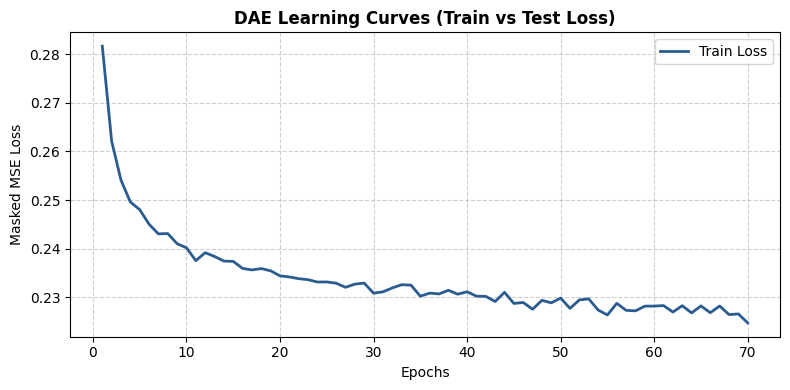

In [8]:
feature_cols = ['GR', 'RHOB', 'NPHI', 'BS', 'DTC', 'DTS', 'CALI']

observed_mask = (~data[feature_cols].isna()).astype(int).values

df_filled = data[feature_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filled)

dae_model = DAEImputerModified(in_features=len(feature_cols), latent=16)
train_dae(dae_model, X_scaled, observed_mask, corruption_rate=0.3, epochs=70)

X_imputed_scaled = impute_logs(dae_model, X_scaled, observed_mask)

df_imputed = pd.DataFrame(
    scaler.inverse_transform(X_imputed_scaled), 
    columns=feature_cols, 
    index=data.index
)

In [12]:
import sys
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

from src.models.rf_cb_optuna import RandomForest


BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.models.baseline import Baseline
from src.metrics import LithologyEvaluator

def run_dae_rf_experiment(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "FORCE_2020_LITHOFACIES_LITHOLOGY",
    latent_dim: int = 16,
    epochs: int = 40,
    reports_dir: str = "reports/figures/dae_modified",
):
    """
    Полный цикл: DAE-импутация -> Baseline classification -> Метрики и графики.
    """
    print("=" * 50)
    print("ЗАПУСК: DAE + RF")
    print("=" * 50)

    print("\n[1/4] Подготовка масок и StandardScaler...")
    X_raw = df[feature_cols].values
    observed_mask = ~np.isnan(X_raw)

    scaler = StandardScaler()
    X_filled_temp = df[feature_cols].fillna(df[feature_cols].median()).values
    X_scaled = scaler.fit_transform(X_filled_temp)

    X_scaled_input = np.where(observed_mask, X_scaled, 0.0)

    print(f"\n[2/4] Обучение DAE (latent_dim={latent_dim}, epochs={epochs})...")
    dae_model = DAEImputerModified(in_features=len(feature_cols), latent=16)
    
    train_dae(
        model=dae_model,
        X_scaled=X_scaled_input,
        observed_mask=observed_mask.astype(np.float32),
        corruption_rate=0.3,
        epochs=epochs,
        batch_size=256,
        lr=1e-3,
    )

    print("\n[3/4] Восстановление пропусков через DAE...")
    dae_model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(X_scaled_input, dtype=torch.float32)
        reconstructed_scaled = dae_model(x_tensor).numpy()

    X_imputed_scaled = np.where(observed_mask, X_scaled, reconstructed_scaled)
    X_imputed = scaler.inverse_transform(X_imputed_scaled)


    df_dae = df.copy()
    df_dae[feature_cols] = X_imputed

   
    print("\n[4/4] Обучение и оценка RF на DAE-данных...")
    trainer = RandomForest(test_size=0.2, random_state=42)
    metrics = trainer.fit_eval(df_dae)


    val_preds = trainer.predict(trainer.X_val)
    val_probs = trainer.predict_proba(trainer.X_val)
    classes = trainer.pipeline.classes_

    evaluator = LithologyEvaluator()
    evaluator.plot_all(
        y_true=trainer.y_val,
        y_pred=val_preds,
        val_probs=val_probs,
        classes=classes,
        output_dir=reports_dir,
    )

    print("\n" + "=" * 50)
    print(f"Отчеты сохранены в: {reports_dir}")
    print("=" * 50)

    return metrics, df_dae

ЗАПУСК: DAE + RF

[1/4] Подготовка масок и StandardScaler...

[2/4] Обучение DAE (latent_dim=16, epochs=50)...
Epoch 01/50 | Train Loss: 0.76103
Epoch 10/50 | Train Loss: 0.63527
Epoch 20/50 | Train Loss: 0.60768
Epoch 30/50 | Train Loss: 0.59611
Epoch 40/50 | Train Loss: 0.58272
Epoch 50/50 | Train Loss: 0.56790


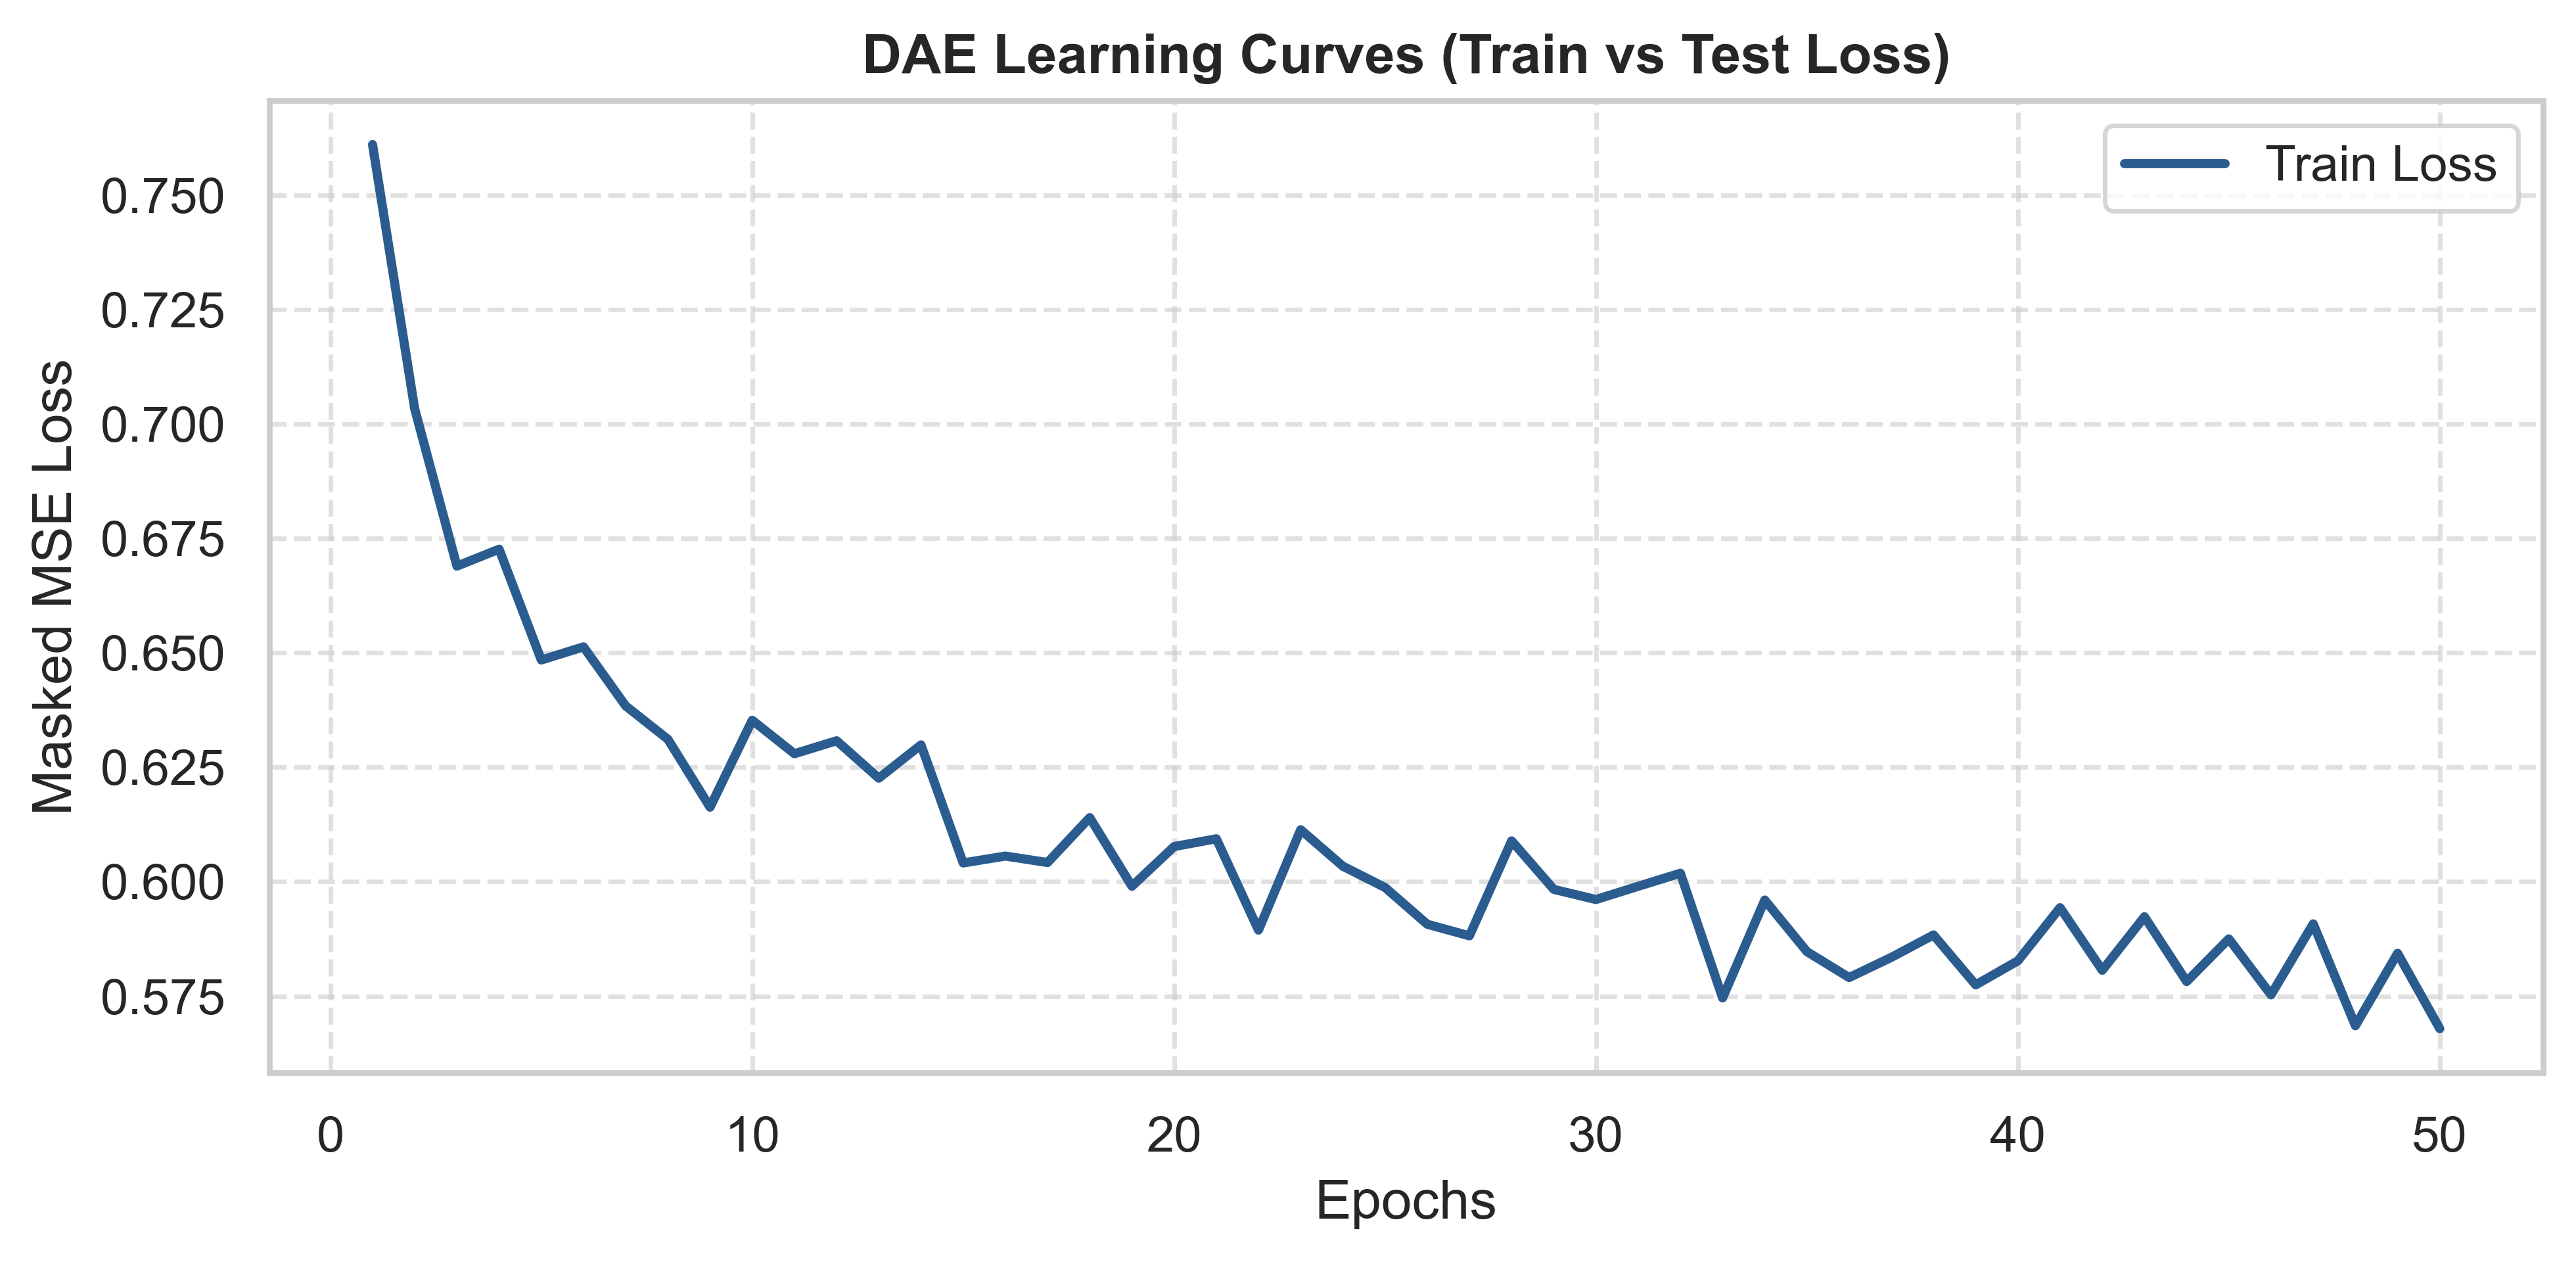


[3/4] Восстановление пропусков через DAE...

[4/4] Обучение и оценка RF на DAE-данных...
Обучение RandomForest (Baseline) >>> 

Отчет по классификации (Validation):
              precision    recall  f1-score   support

       30000       0.76      0.77      0.77     37982
       65000       0.81      0.97      0.88    176056
       65030       0.55      0.06      0.11     29272
       70000       0.65      0.70      0.67     12431
       70032       0.94      0.28      0.43      2575
       74000       0.00      0.00      0.00       495
       80000       0.63      0.27      0.37     10940
       86000       0.64      0.52      0.57       240
       88000       0.97      0.96      0.96      3899
       90000       0.80      0.47      0.59       514
       99000       0.67      0.87      0.76      1838

    accuracy                           0.79    276242
   macro avg       0.68      0.53      0.56    276242
weighted avg       0.77      0.79      0.75    276242



/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Матрица ошибок сохранена в: reports/figures/dae_modified/confusion_matrix.png


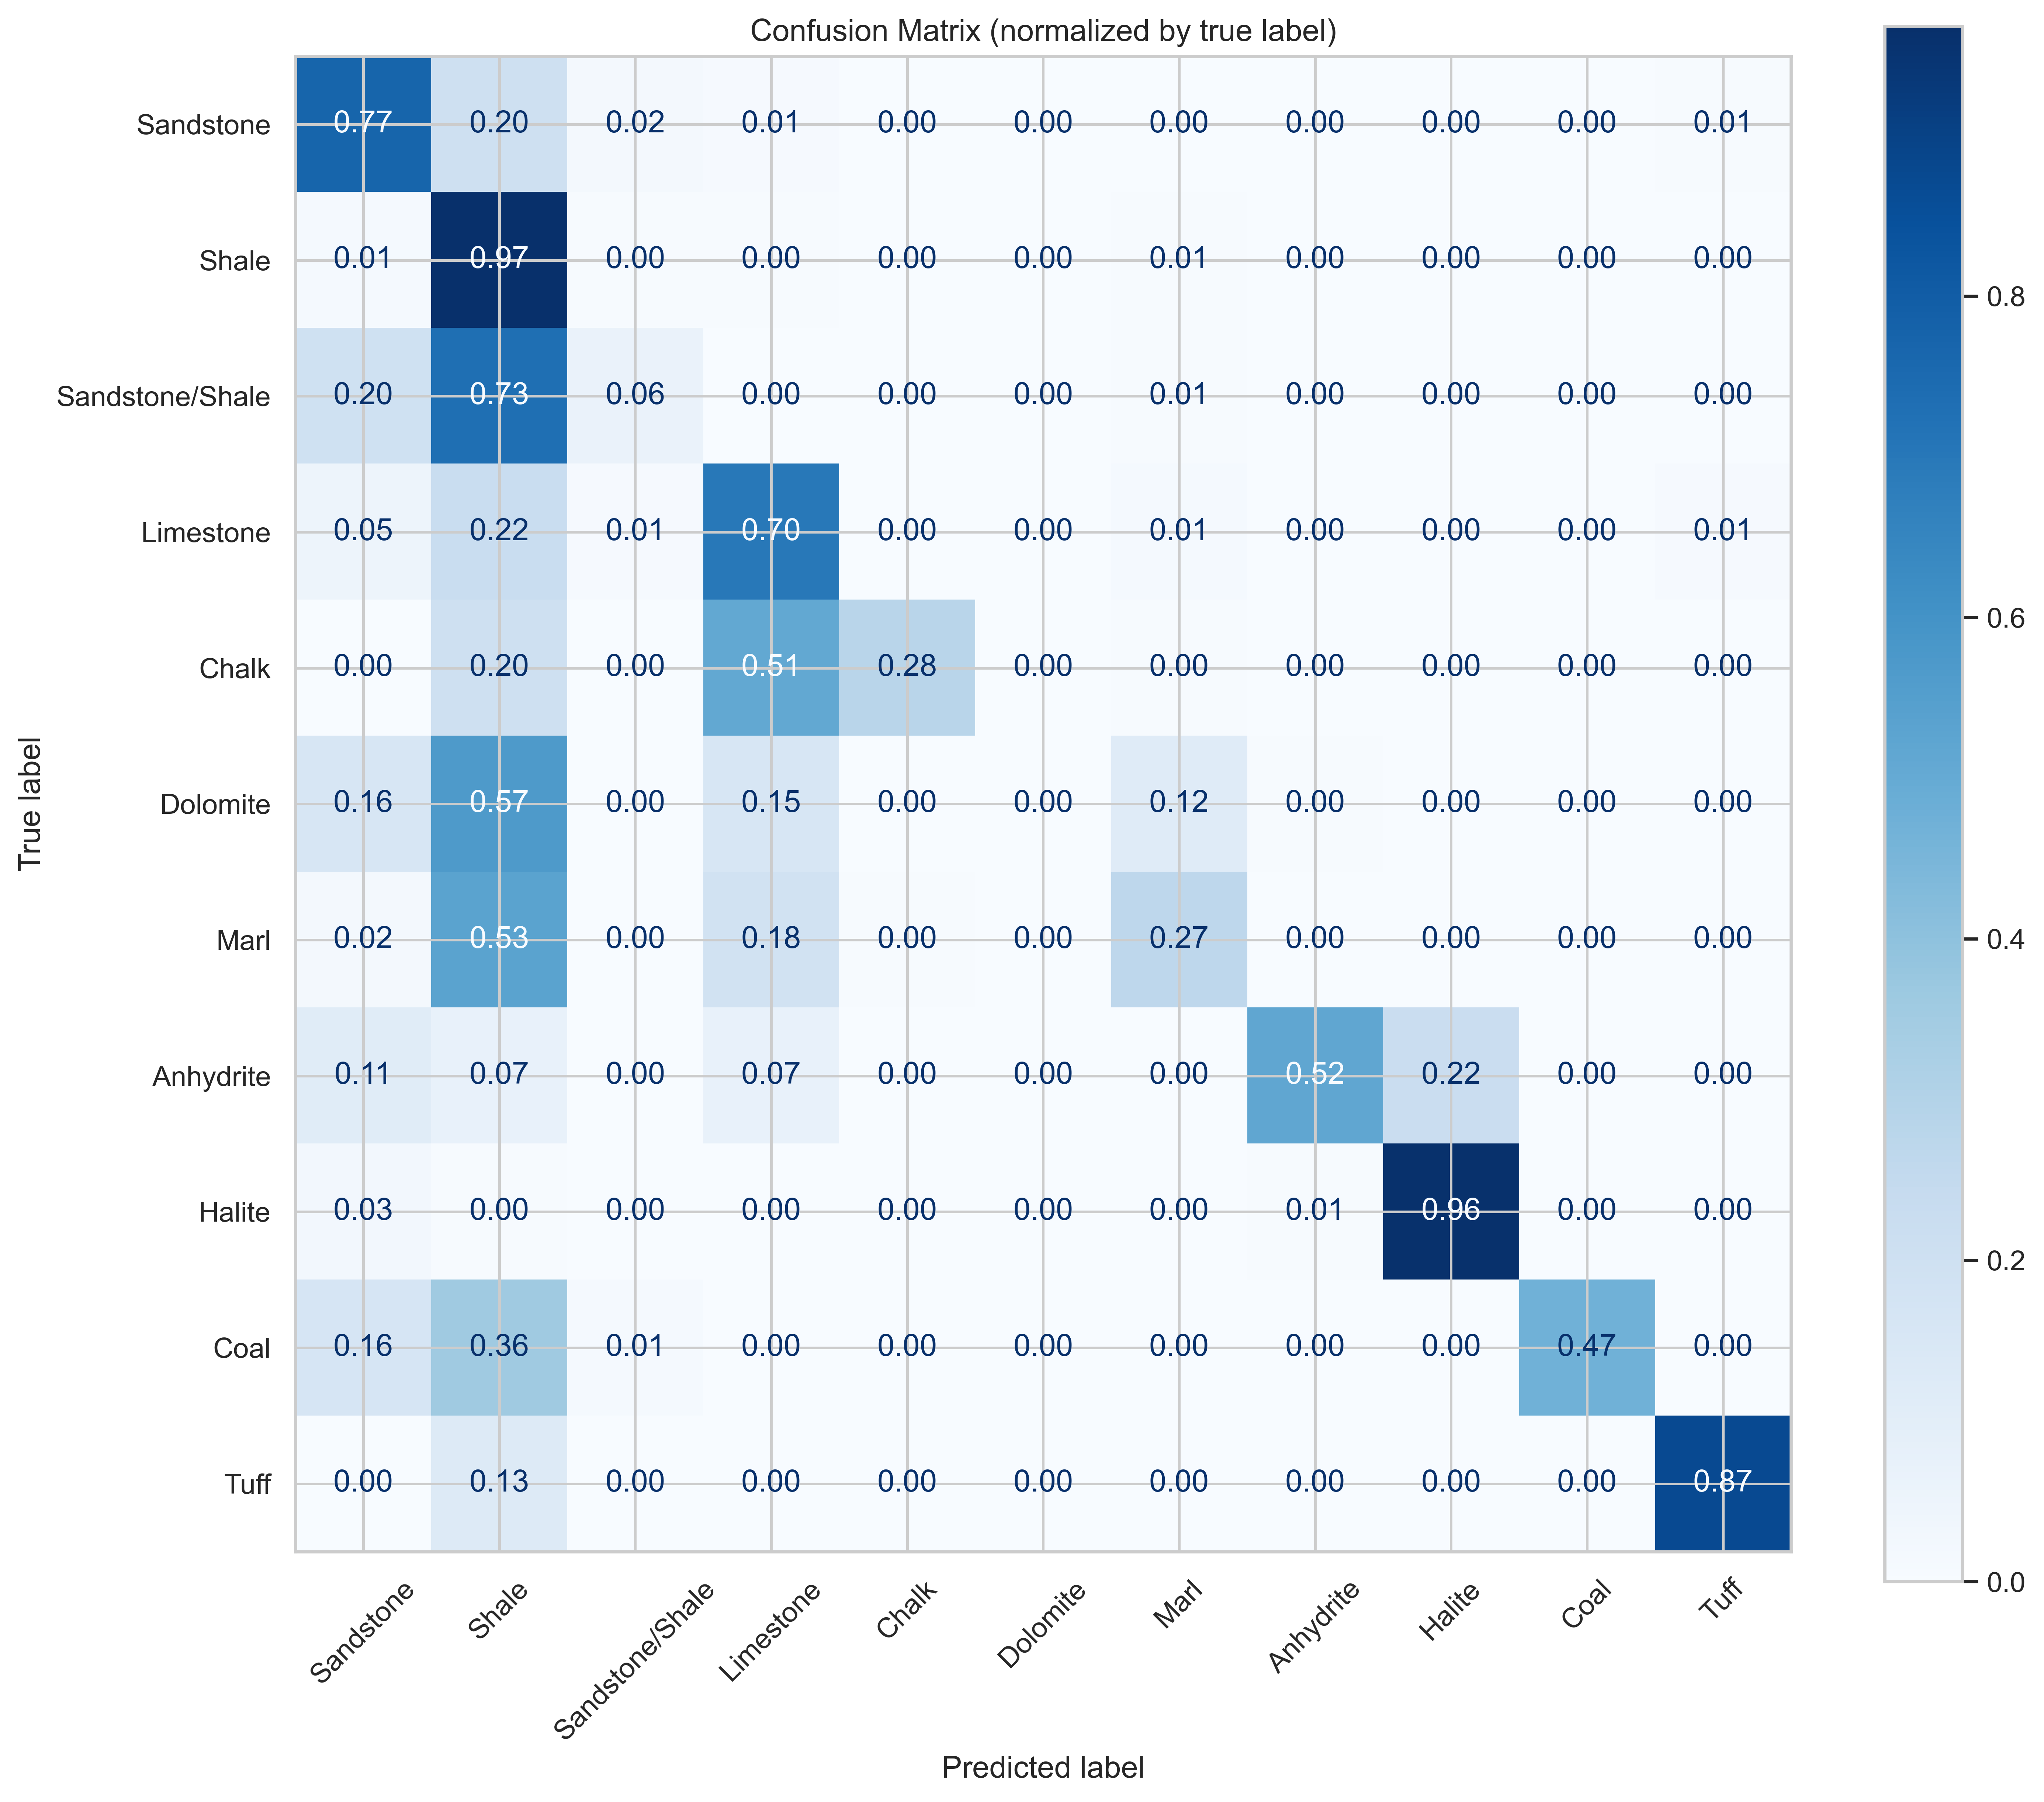

ROC-AUC графики сохранены в: reports/figures/dae_modified/roc_auc_curves.png


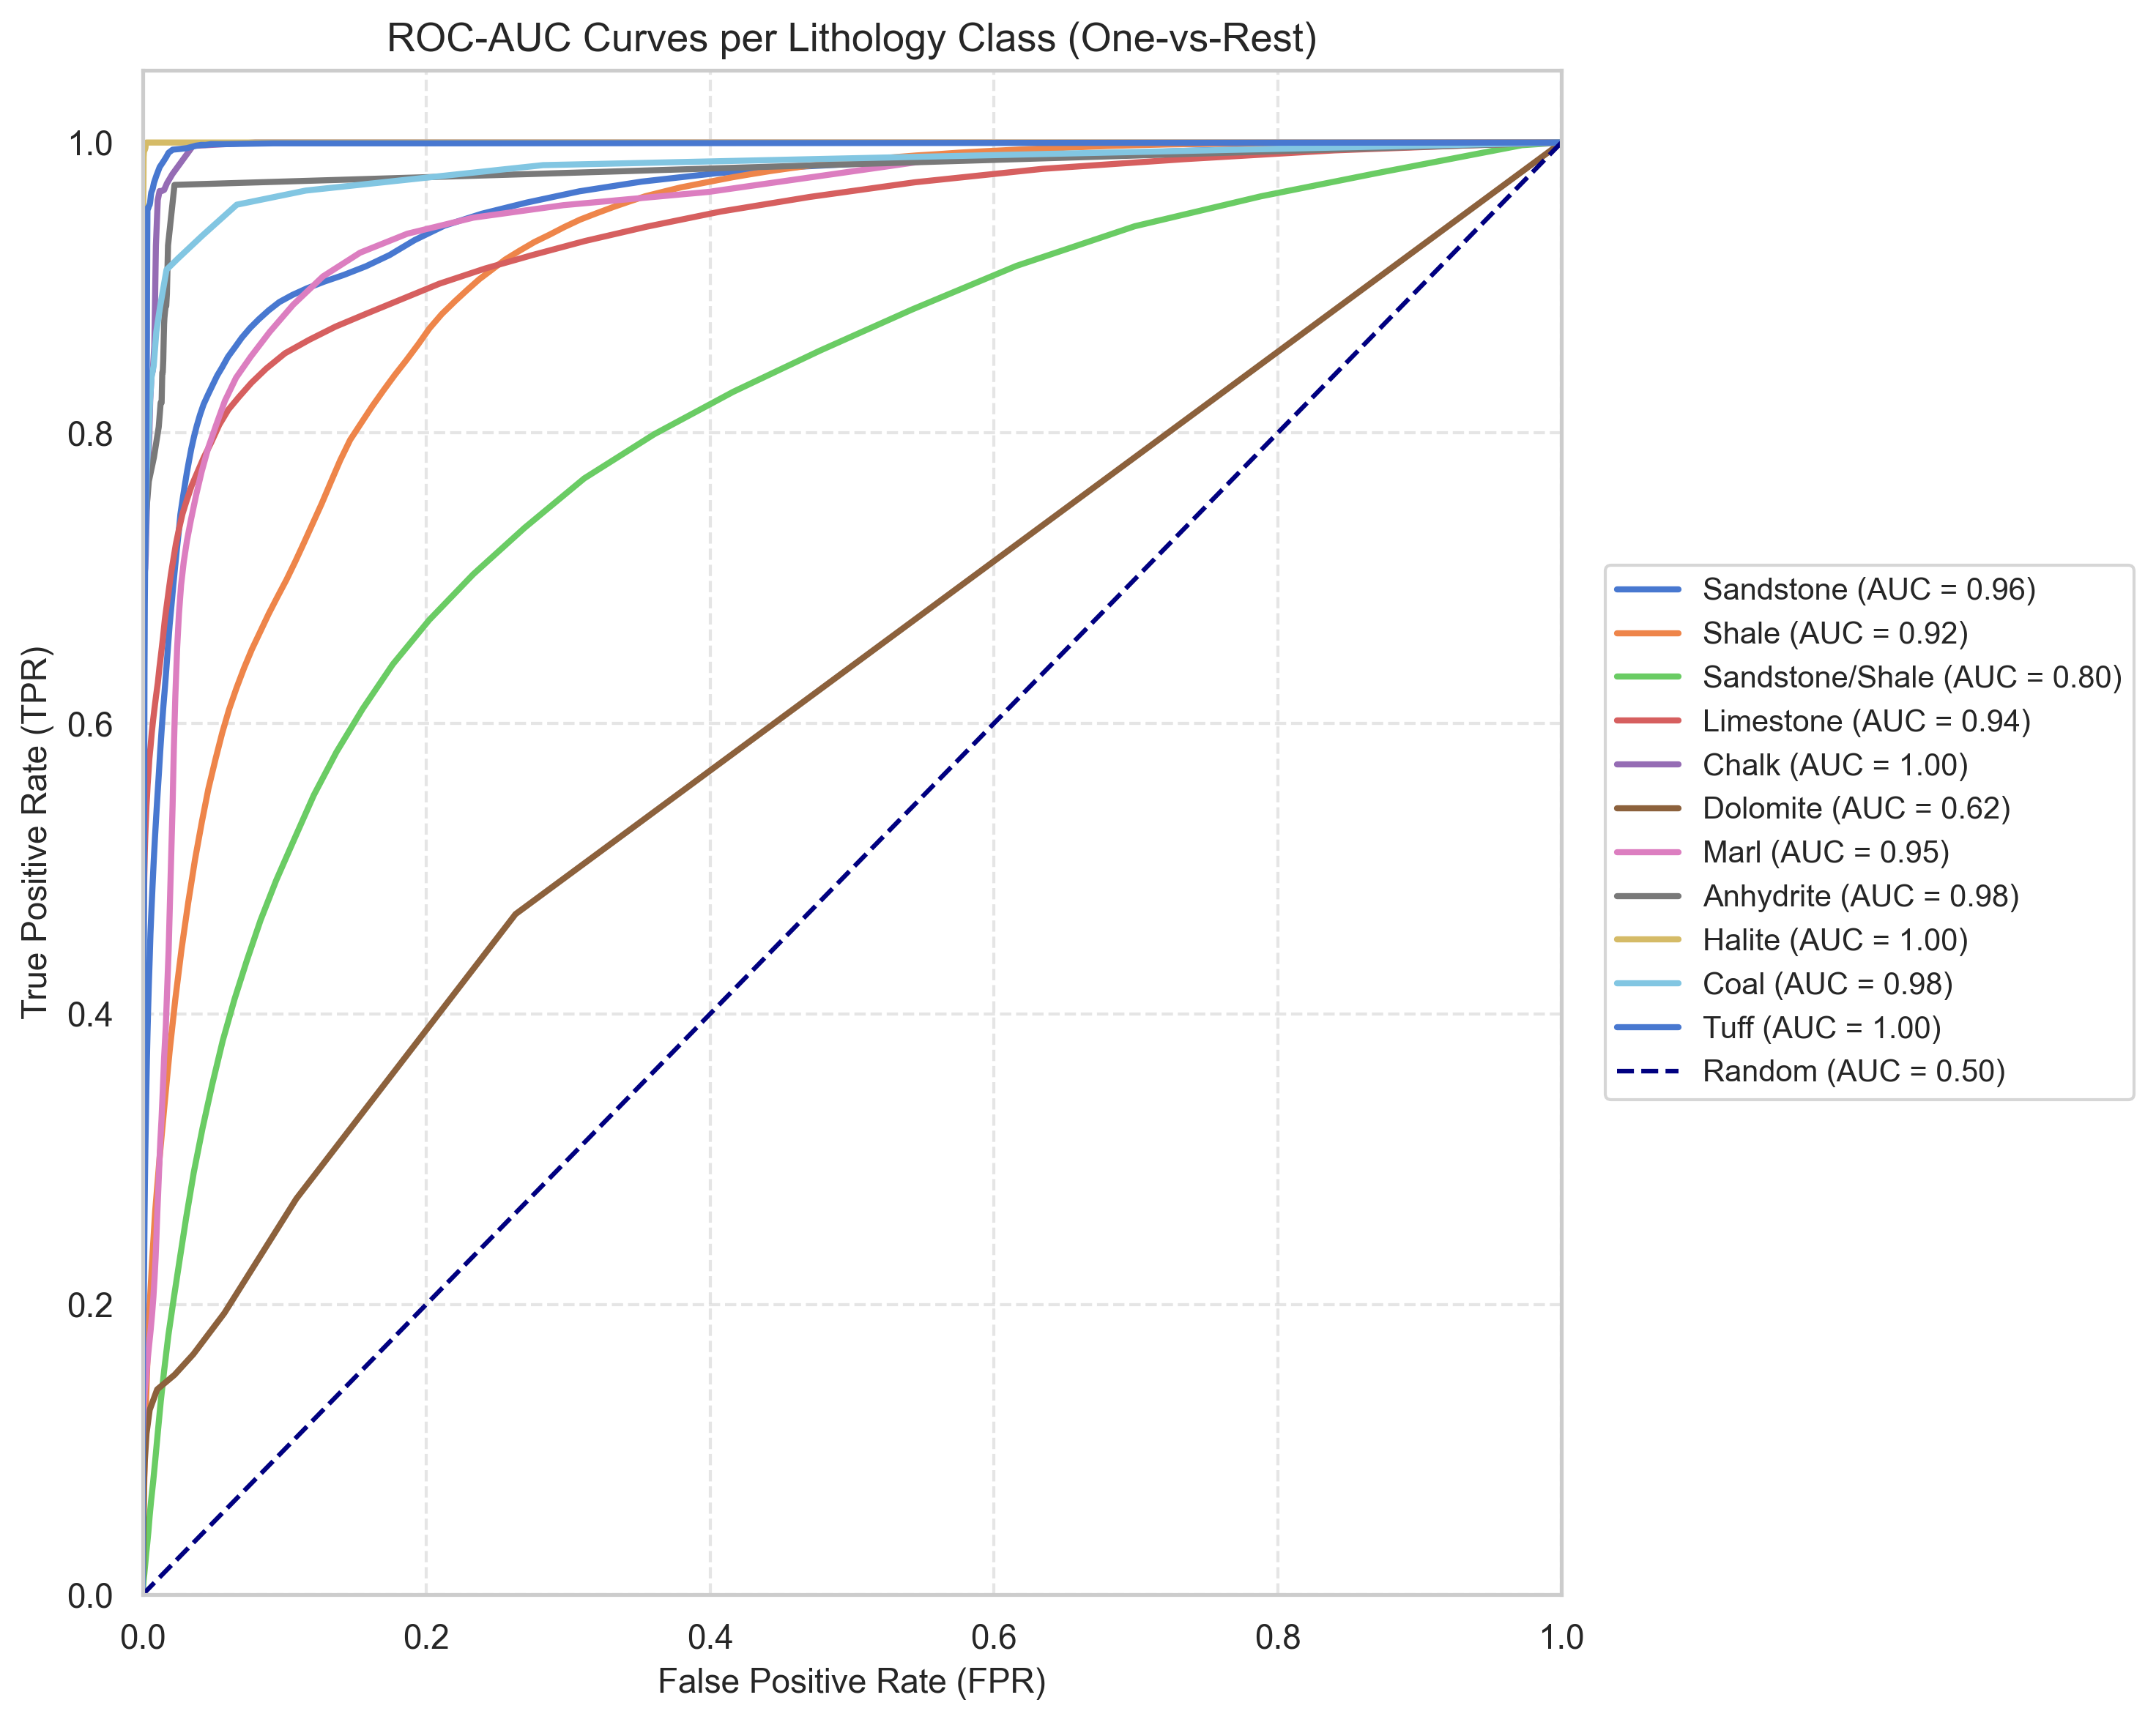


Отчеты сохранены в: reports/figures/dae_modified


In [13]:
feature_cols = ['RDEP', 'RMED', 'RSHA', 'RHOB', 'GR', 'NPHI', 'DTC']

metrics, df_imputed = run_dae_rf_experiment(
    df=data, 
    feature_cols=feature_cols,
    latent_dim=16,
    epochs=50
)